<a href="https://colab.research.google.com/github/debi201326/Shallow-and-Deep-Learning/blob/main/SDL_Practical_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Car Price Prediction Using Artificial Neural Networks

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
df = pd.read_csv("cardekho.csv")

In [ ]:
df.dropna(inplace=True)
df = df[df['selling_price'] > 0]

In [ ]:
X = df.drop(['selling_price', 'name'], axis=1)
y = df['selling_price']

In [ ]:
numeric_features = ['year', 'km_driven', 'engine', 'seats']
categorical_features = ['fuel', 'seller_type', 'transmission', 'owner']

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop='first'), categorical_features)
])



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [ ]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_transformed.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')




In [ ]:
history = model.fit(X_train_transformed, y_train, validation_split=0.2, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1211527987200.0000 - val_loss: 1136838180864.0000
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 910707326976.0000 - val_loss: 1130301620224.0000
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1029408555008.0000 - val_loss: 1113024757760.0000
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 932836343808.0000 - val_loss: 1080514052096.0000
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 914449563648.0000 - val_loss: 1032176336896.0000
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 900988993536.0000 - val_loss: 970450927616.0000
Epoch 7/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 817253777408.0000 - val_loss: 899638099968.0000
Epoch 8/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 867102556160.0000 - val_loss: 825352585216.0000
Epoch 9/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 714556571648.0000 - val_loss: 756485128192.0000
Epoch 10/100

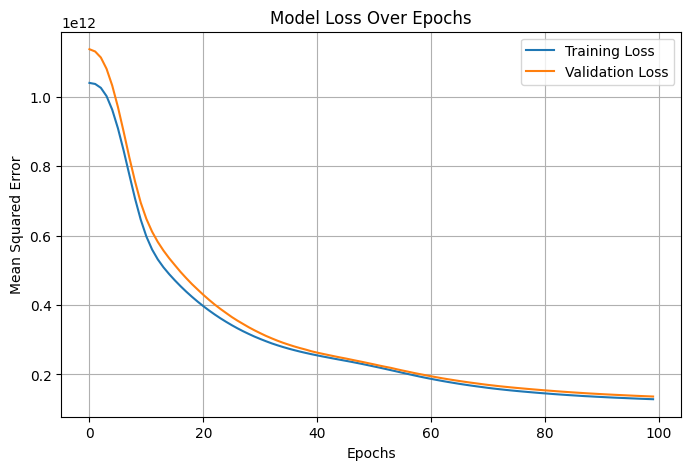

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_pred = model.predict(X_test_transformed).flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"\nRMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

RMSE: 356882.62
R² Score: 0.83


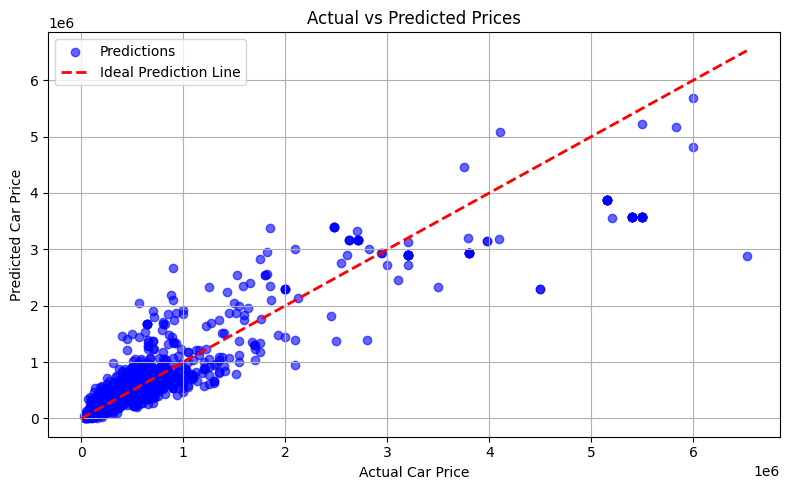

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', label='Predictions')

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction Line')

plt.xlabel('Actual Car Price')
plt.ylabel('Predicted Car Price')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()